In [90]:
from objects.FreeGroup import *
from graph_tool.all import Graph, graph_draw

In [91]:
def sgn(x : int) -> int:
    if x == 0: return 0
    else: return int(abs(x)/x)

In [103]:
def make_whitehead_pairs(group : FreeGroup, word : Word) -> list[tuple[int, int]]:
    pairs : list[tuple[int, int]] = []
    indices = group.alphabet
    for i in range(len(word.word)):
        currElem = word.word[i]
        nextIndex = 0 if i == len(word.word) - 1 else i + 1
        nextElem = word.word[nextIndex]
        pairs.append((indices.index(Elem(nextElem.sym, sgn(nextElem.exp))), indices.index(Elem(currElem.sym, -sgn(currElem.exp)))))
    return pairs

In [107]:
def make_whitehead_graph(group : FreeGroup, word : Word) -> Graph:
    g : Graph = Graph(directed = False)
    g.add_edge_list([(i,) for i in group.alphabet], hashed=True, hash_type="object")
    g.add_edge_list(make_whitehead_pairs(group, word))
    return g

In [112]:
w, l = genRandWord(getFreeGroup(3), 20, 5)
w
make_whitehead_pairs(getFreeGroup(3), w)

[(4, 1),
 (0, 5),
 (3, 1),
 (0, 2),
 (4, 1),
 (1, 5),
 (5, 0),
 (1, 4),
 (5, 0),
 (0, 4)]

a⁻¹b⁻²ab⁴ab⁻⁵


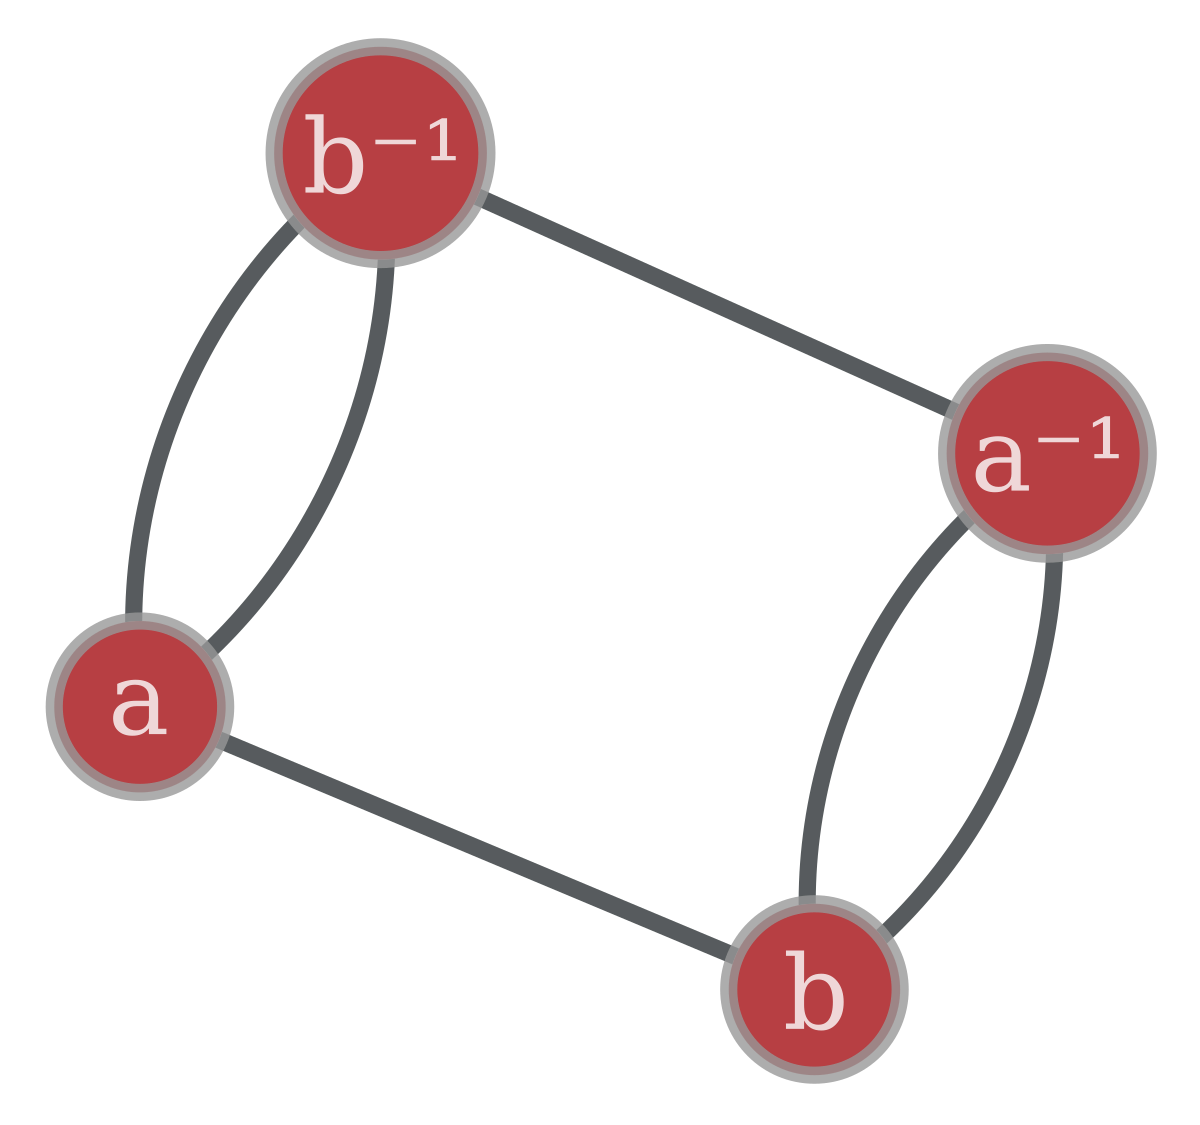

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x7f88398f3ed0, at 0x7f88398dea50>

In [133]:
fg = getFreeGroup(2)
w, l = genRandWord(fg, 10, 5)
print(w)
g = make_whitehead_graph(fg, w)
v_text = g.new_vertex_property("string")
for v in g.vertices():
    v_text[v] = str(fg.alphabet[int(v)])
graph_draw(g, vertex_text=v_text)

In [134]:
def draw_whitehead_graph(fg: FreeGroup, w: Word) -> None:
    g = make_whitehead_graph(fg, w)
    v_text = g.new_vertex_property("string")
    for v in g.vertices():
        v_text[v] = str(fg.alphabet[int(v)])
    graph_draw(g, vertex_text=v_text)